特征值与特征向量
A = 
 [[3 1]
 [1 3]]

特征值: [4.+0.j 2.+0.j]
特征向量:
[[ 0.70710678+0.j -0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]

解释:
  λ₁ = 4.00+0.00j, 对应的特征向量方向: [0.70710678+0.j 0.70710678+0.j]
  λ₂ = 2.00+0.00j, 对应的特征向量方向: [-0.70710678+0.j  0.70710678+0.j]

验证特征向量 1:
  A@v = [2.82842712+0.j 2.82842712+0.j]
  λ*v = [2.82842712+0.j 2.82842712+0.j]
  相等？ True

验证特征向量 2:
  A@v = [-1.41421356+0.j  1.41421356+0.j]
  λ*v = [-1.41421356+0.j  1.41421356+0.j]
  相等？ True


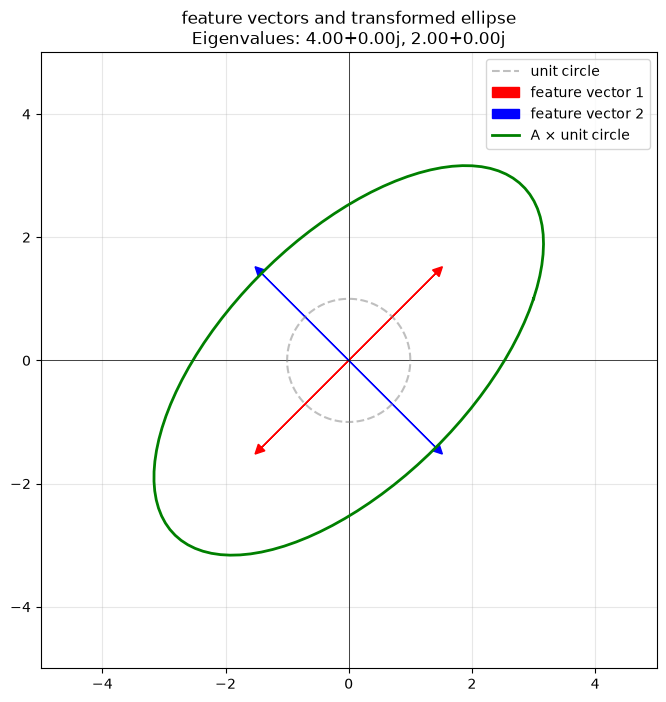

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 创建一个 2x2 矩阵 ----
A = np.array([[3, 1], [1, 3]])

print("=" * 60)
print("特征值与特征向量")
print("=" * 60)
print("A = \n", A)

# ---- 用 np.linalg.eig 计算 ----
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"\n特征值: {eigenvalues}")
print(f"特征向量:\n{eigenvectors}")
print("\n解释:")
print(f"  λ₁ = {eigenvalues[0]:.2f}, 对应的特征向量方向: {eigenvectors[:, 0]}")
print(f"  λ₂ = {eigenvalues[1]:.2f}, 对应的特征向量方向: {eigenvectors[:, 1]}")

# ---- 验证: A @ eigenvector = λ * eigenvector ----
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    Av = A @ v
    lambda_v = eigenvalues[i] * v
    print(f"\n验证特征向量 {i+1}:")
    print(f"  A@v = {Av}")
    print(f"  λ*v = {lambda_v}")
    print(f"  相等？ {np.allclose(Av, lambda_v)}")

# ---- 几何可视化 ----
plt.figure(figsize=(10, 8))

# 原始坐标系
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# 画单位圆
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])
plt.plot(circle[0, :], circle[1, :], 'gray', linestyle='--', alpha=0.5, label='unit circle')

# 画特征向量方向
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    # 两个方向（正反）
    for sign in [1, -1]:
        vec = sign * v.real / np.linalg.norm(v.real) * 2
        plt.arrow(0, 0, vec[0], vec[1], 
                 head_width=0.15, head_length=0.15,
                 fc='red' if i==0 else 'blue',
                 ec='red' if i==0 else 'blue',
                 label=f'feature vector {i+1}' if sign==1 else '')

# 变换后的单位圆（椭圆）
A_circle = A @ circle
plt.plot(A_circle[0, :], A_circle[1, :], 'green', linewidth=2, label='A × unit circle')

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid(alpha=0.3)
plt.title(f'feature vectors and transformed ellipse\nEigenvalues: {eigenvalues[0]:.2f}, {eigenvalues[1]:.2f}')
plt.legend()
plt.gca().set_aspect('equal')
plt.show()